In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import f1_score, 

RANDOM_STATE = 42

In [2]:
data = pd.read_csv("../csv/cl_finished.csv", sep = ';')

In [3]:
X = data.drop(columns=['Diabetes_012'])
y = data['Diabetes_012']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)

In [5]:
y.value_counts()

Diabetes_012
0    190055
2     35097
1      4629
Name: count, dtype: int64

**Классификация - мультиклассовая**

([<matplotlib.patches.Wedge at 0x15c3fcfee40>,
 [Text(-0.941699975714862, 0.5685078326097439, ''),
  Text(0.903858888437878, -0.6269283131202832, ''),
  Text(1.0977977786141369, -0.06957037638152071, '')])

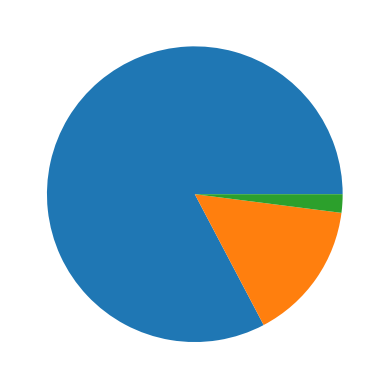

In [6]:
plt.pie(y.value_counts())

Для данной выборки будем использовать **oversampling**

In [7]:
sm = SMOTE(random_state = 42)

X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [ ]:
def objective_logReg(trial):

    penalty = trial.suggest_categorical('pealty', ['l1', 'l2', 'elasticnet'])
    tol = trial.suggest_float('tol', [0.001, 0.0001, 0.00001])
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    max_iter = trial.suggest_int('max_iter', [100, 1000, 5000])

    model = LogisticRegression(penalty = penalty, tol = tol, fit_intercept = fit_intercept, max_iter = max_iter, random_state = RANDOM_STATE)

    model.fit(X_train_resampled, y_train_resampled)

    pred = model.predict(X_test, y_test)

    return f1_score(y_test, pred)

In [9]:
logReg_model = LogisticRegression()
